# Week 11 exercises

### Ex 11.1

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

K = np.loadtxt('K.txt')
im0 = cv2.imread('sequence/000001.png')
im1 = cv2.imread('sequence/000002.png')
im2 = cv2.imread('sequence/000003.png')

In [2]:
sift = cv2.SIFT_create(nfeatures=2000)

kp0, des0 = sift.detectAndCompute(im0, None)
kp1, des1 = sift.detectAndCompute(im1, None)
kp2, des2 = sift.detectAndCompute(im2, None)

kp0 = np.array([k.pt for k in kp0])
kp1 = np.array([k.pt for k in kp1])
kp2 = np.array([k.pt for k in kp2])

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

matches01 = bf.match(des0, des1)
matches12 = bf.match(des1, des2)

matches01 = np.array([(m.queryIdx, m.trainIdx) for m in matches01])
matches12 = np.array([(m.queryIdx, m.trainIdx) for m in matches12])

### 11.2

In [3]:
pts0 = kp0[matches01[:, 0]]
pts1 = kp1[matches01[:, 1]]

E, mask_E = cv2.findEssentialMat(pts0, pts1, K, method=cv2.RANSAC,
                                  prob=0.999, threshold=1.0)

_, R1, t1, mask_pose = cv2.recoverPose(E, pts0, pts1, K, mask=mask_E)

inlier_mask = (mask_E.ravel() != 0) & (mask_pose.ravel() != 0)
matches01 = matches01[inlier_mask]

### Ex 11.3

In [4]:
_, idx01, idx12 = np.intersect1d(matches01[:, 1], matches12[:, 0], return_indices=True)

points0 = kp0[matches01[idx01, 0]]
points1 = kp1[matches01[idx01, 1]]   # == kp1[matches12[idx12, 0]]
points2 = kp2[matches12[idx12, 1]]

### Ex 11.4

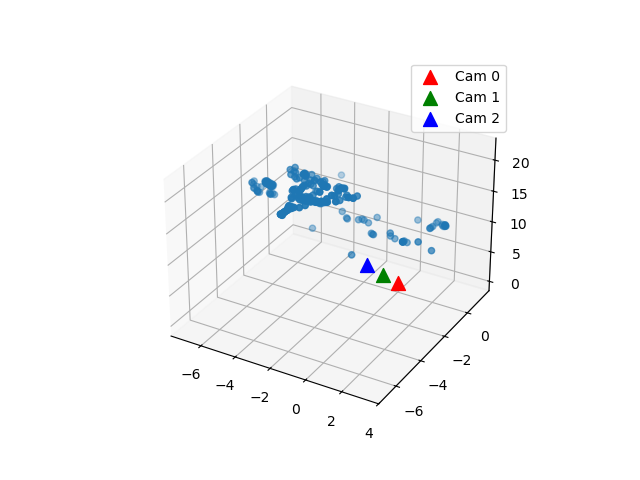

In [5]:
%matplotlib widget
# --- Triangulate 3D points from image 0 & image 1 ---
P0 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))       # camera 0 at origin
P1 = K @ np.hstack((R1, t1))                              # camera 1 pose from ex 11.2

Q_hom = cv2.triangulatePoints(P0, P1, points0.T.astype(np.float64), points1.T.astype(np.float64))
Q = Q_hom[:3] / Q_hom[3]

# --- Estimate pose of camera 2 with PnP RANSAC ---
distCoeffs = np.zeros(5)
success, rvec2, t2, inliers = cv2.solvePnPRansac(
    Q.T.astype(np.float64), points2.astype(np.float64), K, distCoeffs
)
R2, _ = cv2.Rodrigues(rvec2)

# --- Visualize inlier 3D points ---
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*Q[:, inliers.flatten()])

# --- Camera positions in world coordinates ---
C0 = np.zeros(3)              # camera 0 is world origin
C1 = -R1.T @ t1.flatten()     # camera 1 position
C2 = -R2.T @ t2.flatten()     # camera 2 position

ax.scatter(*C0, c='r', marker='^', s=100, label='Cam 0')
ax.scatter(*C1, c='g', marker='^', s=100, label='Cam 1')
ax.scatter(*C2, c='b', marker='^', s=100, label='Cam 2')
ax.legend()
plt.show()

### Ex 11.5

In [6]:
import glob
import numpy as np
import cv2

# --- Load all images ---
paths = sorted(glob.glob('sequence/*.png'))
n = len(paths)
ims = [cv2.imread(p) for p in paths]

# --- SIFT on every frame ---
sift = cv2.SIFT_create(nfeatures=2000)
kps, dess = [], []
for im in ims:
    k, d = sift.detectAndCompute(im, None)
    kps.append(np.array([kk.pt for kk in k]))
    dess.append(d)

# --- Match consecutive pairs: matches[i] links frame i -> i+1 ---
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = []
for i in range(n - 1):
    m = bf.match(dess[i], dess[i + 1])
    matches.append(np.array([(mm.queryIdx, mm.trainIdx) for mm in m]))

# --- Bootstrap: essential matrix between frame 0 and 1 ---
pts0 = kps[0][matches[0][:, 0]]
pts1 = kps[1][matches[0][:, 1]]

E, mask_E = cv2.findEssentialMat(pts0, pts1, K, method=cv2.RANSAC,
                                  prob=0.999, threshold=1.0)
_, R1, t1, mask_pose = cv2.recoverPose(E, pts0, pts1, K, mask=mask_E)

inlier = (mask_E.ravel() != 0) & (mask_pose.ravel() != 0)
matches[0] = matches[0][inlier]

Rs = {0: np.eye(3), 1: R1}
ts = {0: np.zeros((3, 1)), 1: t1}
Q_by_frame = {}

MIN_INLIERS = 50

# --- Iterate: for each new frame, triangulate from the two before it, then PnP ---
for i in range(2, n):
    m_prev = matches[i - 2]   # frame i-2 -> i-1
    m_curr = matches[i - 1]   # frame i-1 -> i

    _, idxA, idxB = np.intersect1d(m_prev[:, 1], m_curr[:, 0], return_indices=True)

    pA = kps[i - 2][m_prev[idxA, 0]]
    pB = kps[i - 1][m_prev[idxA, 1]]
    pC = kps[i][m_curr[idxB, 1]]

    if len(pA) < 6:
        print(f'frame {i}: only {len(pA)} tracks — reusing previous pose')
        Rs[i] = Rs[i - 1]; ts[i] = ts[i - 1]
        continue

    PA = K @ np.hstack((Rs[i - 2], ts[i - 2]))
    PB = K @ np.hstack((Rs[i - 1], ts[i - 1]))

    Qh = cv2.triangulatePoints(PA, PB, pA.T.astype(np.float64), pB.T.astype(np.float64))
    Q = Qh[:3] / Qh[3]

    ok, rvec, tvec, inl = cv2.solvePnPRansac(
        Q.T.astype(np.float64), pC.astype(np.float64), K, np.zeros(5)
    )

    n_inliers = 0 if inl is None else len(inl)

    if not ok or n_inliers < MIN_INLIERS:
        print(f'frame {i}: {len(pA)} tracks, {n_inliers} PnP inliers — below threshold, reusing previous pose')
        Rs[i] = Rs[i - 1]; ts[i] = ts[i - 1]
        continue

    R, _ = cv2.Rodrigues(rvec)
    Rs[i] = R
    ts[i] = tvec
    Q_by_frame[i] = Q[:, inl.flatten()]
    print(f'frame {i}: {len(pA)} tracks, {n_inliers} PnP inliers')

# --- Camera centres in world coordinates ---
frames_sorted = sorted(Rs.keys())
Cs = np.array([(-Rs[i].T @ ts[i].flatten()) for i in frames_sorted])
Q_all = np.hstack(list(Q_by_frame.values()))

# --- Frame-to-frame displacement (sanity check) ---
for idx in range(1, len(frames_sorted)):
    print(frames_sorted[idx], np.linalg.norm(Cs[idx] - Cs[idx - 1]))

frame 2: 360 tracks, 273 PnP inliers
frame 3: 490 tracks, 271 PnP inliers
frame 4: 502 tracks, 285 PnP inliers
frame 5: 588 tracks, 375 PnP inliers
frame 6: 533 tracks, 335 PnP inliers
frame 7: 550 tracks, 362 PnP inliers
frame 8: 552 tracks, 344 PnP inliers
frame 9: 486 tracks, 298 PnP inliers
frame 10: 462 tracks, 246 PnP inliers
frame 11: 440 tracks, 248 PnP inliers
frame 12: 460 tracks, 278 PnP inliers
frame 13: 435 tracks, 235 PnP inliers
frame 14: 301 tracks, 26 PnP inliers — below threshold, reusing previous pose
frame 15: 262 tracks, 0 PnP inliers — below threshold, reusing previous pose
frame 16: 308 tracks, 0 PnP inliers — below threshold, reusing previous pose
frame 17: 225 tracks, 0 PnP inliers — below threshold, reusing previous pose
frame 18: 222 tracks, 0 PnP inliers — below threshold, reusing previous pose
frame 19: 220 tracks, 0 PnP inliers — below threshold, reusing previous pose
1 0.9999999999999999
2 1.265892871962742
3 1.7392398521741521
4 1.2751488408525087
5 1.23

In [7]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=Q_all[0], y=Q_all[1], z=Q_all[2],
    mode='markers', marker=dict(size=1.5, color='lightgray'),
    name='3D points'
))

fig.add_trace(go.Scatter3d(
    x=Cs[:, 0], y=Cs[:, 1], z=Cs[:, 2],
    mode='lines+markers',
    marker=dict(size=4, color=np.arange(len(Cs)), colorscale='Viridis'),
    line=dict(width=3, color='red'),
    name='Camera trajectory'
))

fig.update_layout(scene=dict(aspectmode='data'), width=900, height=750)
fig.show()

### Ex 11.6

In [9]:
from collections import defaultdict

# --- Build global feature tracks by chaining consecutive matches ---
track_id_map = {}                # (frame_idx, kp_idx) -> track_id
tracks = defaultdict(dict)        # track_id -> {frame_idx: kp_idx}
next_track_id = 0

for i in range(n - 1):
    for q, t in matches[i]:
        key0 = (i, q)
        if key0 in track_id_map:
            tid = track_id_map[key0]
        else:
            tid = next_track_id
            next_track_id += 1
            track_id_map[key0] = tid
            tracks[tid][i] = q
        track_id_map[(i + 1, t)] = tid
        tracks[tid][i + 1] = t

# --- Multi-view triangulation via DLT ---
def triangulate_multiview(Ps, pts):
    A = []
    for P, (x, y) in zip(Ps, pts):
        A.append(x * P[2] - P[0])
        A.append(y * P[2] - P[1])
    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    Qh = Vt[-1]
    return Qh[:3] / Qh[3]

# --- Bootstrap: essential matrix between frame 0 and 1 (unchanged) ---
pts0 = kps[0][matches[0][:, 0]]
pts1 = kps[1][matches[0][:, 1]]

E, mask_E = cv2.findEssentialMat(pts0, pts1, K, method=cv2.RANSAC,
                                  prob=0.999, threshold=1.0)
_, R1, t1, mask_pose = cv2.recoverPose(E, pts0, pts1, K, mask=mask_E)

inlier = (mask_E.ravel() != 0) & (mask_pose.ravel() != 0)
matches[0] = matches[0][inlier]
# Note: tracks were built from matches[0] before filtering above ran;
# rebuild tracks after this filtering step if you want the bootstrap
# inlier cleanup reflected in the track table (rerun the track-building
# loop above after this point, or filter matches[0] before building tracks).

Rs = {0: np.eye(3), 1: R1}
ts = {0: np.zeros((3, 1)), 1: t1}
Q_by_frame = {}
MIN_INLIERS = 50

for i in range(2, n):
    points3d, points2d = [], []

    for tid, obs in tracks.items():
        if i not in obs:
            continue
        prior_frames = [f for f in obs if f in Rs and f != i]   # only genuinely localized frames
        if len(prior_frames) < 2:
            continue

        Ps = [K @ np.hstack((Rs[f], ts[f])) for f in prior_frames]
        pts = [kps[f][obs[f]] for f in prior_frames]

        Q = triangulate_multiview(Ps, pts)
        points3d.append(Q)
        points2d.append(kps[i][obs[i]])

    points3d = np.array(points3d)
    points2d = np.array(points2d)

    if len(points3d) < 6:
        print(f'frame {i}: only {len(points3d)} usable tracks — could not localize, skipping')
        continue   # do NOT write Rs[i]/ts[i] — leave frame unlocalized

    ok, rvec, tvec, inl = cv2.solvePnPRansac(
        points3d.astype(np.float64), points2d.astype(np.float64), K, np.zeros(5)
    )
    n_inliers = 0 if inl is None else len(inl)

    if not ok or n_inliers < MIN_INLIERS:
        print(f'frame {i}: {len(points3d)} tracks, {n_inliers} PnP inliers — below threshold, skipping')
        continue   # again, don't write a pose

    R, _ = cv2.Rodrigues(rvec)
    Rs[i] = R
    ts[i] = tvec
    Q_by_frame[i] = points3d[inl.flatten()]
    print(f'frame {i}: {len(points3d)} tracks, {n_inliers} PnP inliers')

frame 2: 329 tracks, 253 PnP inliers
frame 3: 490 tracks, 272 PnP inliers
frame 4: 502 tracks, 271 PnP inliers
frame 5: 588 tracks, 333 PnP inliers
frame 6: 533 tracks, 303 PnP inliers
frame 7: 550 tracks, 315 PnP inliers
frame 8: 552 tracks, 280 PnP inliers
frame 9: 486 tracks, 253 PnP inliers
frame 10: 462 tracks, 205 PnP inliers
frame 11: 440 tracks, 160 PnP inliers
frame 12: 460 tracks, 223 PnP inliers
frame 13: 435 tracks, 57 PnP inliers
frame 14: 301 tracks, 14 PnP inliers — below threshold, skipping
frame 15: 151 tracks, 0 PnP inliers — below threshold, skipping
frame 16: 87 tracks, 6 PnP inliers — below threshold, skipping
frame 17: 30 tracks, 0 PnP inliers — below threshold, skipping
frame 18: 14 tracks, 0 PnP inliers — below threshold, skipping
frame 19: 9 tracks, 0 PnP inliers — below threshold, skipping


In [11]:
import plotly.graph_objects as go

frames_sorted = sorted(Rs.keys())
Cs = np.array([(-Rs[i].T @ ts[i].flatten()) for i in frames_sorted])

# Q_by_frame[i] is (K,3) — points as rows — so vstack then transpose for x,y,z columns
Q_all = np.vstack(list(Q_by_frame.values())).T   # (3, total_points)

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=Q_all[0], y=Q_all[1], z=Q_all[2],
    mode='markers', marker=dict(size=1.5, color='lightgray'),
    name='3D points'
))

fig.add_trace(go.Scatter3d(
    x=Cs[:, 0], y=Cs[:, 1], z=Cs[:, 2],
    mode='lines+markers',
    marker=dict(size=4, color=np.arange(len(Cs)), colorscale='Viridis'),
    line=dict(width=3, color='red'),
    name='Camera trajectory'
))

# annotate which frame each camera marker corresponds to
fig.add_trace(go.Scatter3d(
    x=Cs[:, 0], y=Cs[:, 1], z=Cs[:, 2],
    mode='text', text=[str(f) for f in frames_sorted],
    textposition='top center', showlegend=False
))

fig.update_layout(scene=dict(aspectmode='data'), width=900, height=750)
fig.show()